# Mini PacMan: deterministic safety-LTL shielding

This tutorial demonstrates the two deterministic shielding interfaces:

1. **Preemptive shielding** — expose the safe-action mask before the policy selects an action.
2. **Postposed shielding** — let the policy propose any action, then replace unsafe proposals.

We use the safety property

$$
\mathbf{G}\neg \texttt{ghost},
$$

meaning PacMan must never enter a state labelled `ghost`.

For the postposed example, unsafe proposals are replaced using `random_safe(seed=...)`.
The randomness only chooses **among actions already certified safe by the winning region**.

This version uses Mini PacMan's **`rgb_array` renderer**, so states and complete
rollouts can be displayed directly inside the notebook.


## 1. Imports

Run this notebook from the MASA-Safe-RL repository root, or from `tutorial/`.


In [ ]:
from pathlib import Path
import sys

repo_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "masa").is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError(
        "Run this notebook from the MASA-Safe-RL repository root or tutorial/."
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

from masa.common.constraints.ltl_safety import LTLSafetyEnv
from masa.common.labelled_env import LabelledEnv
from masa.common.ltl import Atom, DFA
from masa.deterministic_shield import (
    PreemptiveLTLShield,
    PostposedLTLShield,
    random_safe,
)
from masa.envs.tabular.mini_pacman import MiniPacman, label_fn

ENV_SEED = 7
POLICY_SEED = 11
REPLACEMENT_SEED = 42
MAX_STEPS = 80

# print("Repository:", repo_root)


Repository: /var/home/omar/Projects/amethyst/masa/public


## 2. Define the safety DFA

MASA represents safety properties using a DFA whose **accepting states are violation states**.

For `G !ghost` we only need two states:

- `0`: no collision has occurred.
- `1`: a collision has occurred.

The transition `0 -> 1` fires whenever the current label set contains `"ghost"`.


In [16]:
def make_safety_dfa():
    dfa = DFA([0, 1], 0, [1])
    dfa.add_edge(0, 1, Atom("ghost"))
    return dfa


def make_monitored_env():
    base = MiniPacman(
        render_mode="rgb_array",
        render_window_size=512,
    )
    labelled = LabelledEnv(base, label_fn)
    return LTLSafetyEnv(
        labelled,
        dfa=make_safety_dfa(),
        obs_type="discrete",
    )


def show_frame(frame, title=None, figsize=(8, 6)):
    """Display one H x W x 3 uint8 RGB frame inline."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(frame)
    ax.axis("off")
    if title is not None:
        ax.set_title(title)
    plt.show()


def animate_frames(frames, interval=250):
    """Return an inline JavaScript animation for a sequence of RGB frames."""
    if not frames:
        raise ValueError("frames must not be empty")

    fig, ax = plt.subplots(figsize=(8, 6))
    image = ax.imshow(frames[0])
    ax.axis("off")

    def update(i):
        image.set_data(frames[i])
        ax.set_title(f"Step {i}")
        return (image,)

    animation = FuncAnimation(
        fig,
        update,
        frames=len(frames),
        interval=interval,
        blit=False,
        repeat=True,
    )
    plt.close(fig)
    return HTML(animation.to_jshtml())


## 3. Preemptive shielding

The policy sees the mask first and selects only from safe actions.

A preemptive shield does **not** replace an unsafe action. If the caller submits
one anyway, the wrapper should reject it before stepping the environment.


Initial product observation: 1335
Winning product states: 6150 / 18496


,action,safe
0,0,True
1,1,True
2,2,True
3,3,True
4,4,True


RGB frame: (357, 510, 3) uint8


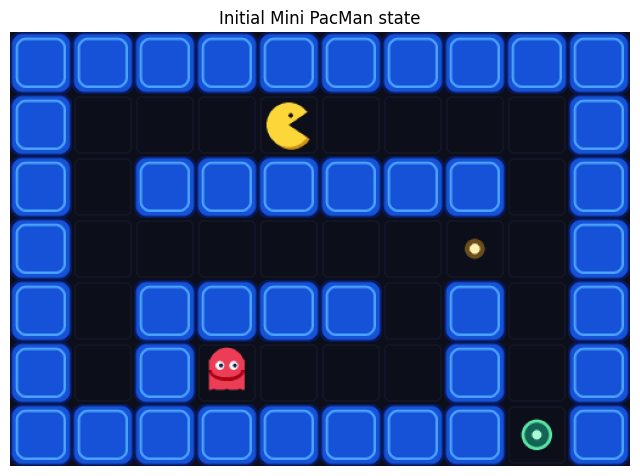

In [17]:
preemptive_env = PreemptiveLTLShield(make_monitored_env())

obs, info = preemptive_env.reset(seed=ENV_SEED)
mask = preemptive_env.action_masks()

print("Initial product observation:", obs)
print("Winning product states:",
      int(preemptive_env.winning_region.sum()),
      "/",
      preemptive_env.observation_space.n)

display(pd.DataFrame({
    "action": np.arange(preemptive_env.action_space.n),
    "safe": mask,
}))

initial_frame = preemptive_env.render()
print("RGB frame:", initial_frame.shape, initial_frame.dtype)
show_frame(initial_frame, "Initial Mini PacMan state")


In [18]:
def run_preemptive(env, steps=MAX_STEPS):
    rng = np.random.default_rng(POLICY_SEED)
    obs, info = env.reset(seed=ENV_SEED)
    rows = []
    frames = [env.render().copy()]

    for t in range(steps):
        mask = env.action_masks()
        safe_actions = np.flatnonzero(mask)
        if safe_actions.size == 0:
            raise RuntimeError("No safe actions in an active winning state.")

        proposed = int(rng.choice(safe_actions))

        next_obs, reward, terminated, truncated, step_info = env.step(proposed)

        executed = int(step_info["shield_executed_action"])
        assert executed == proposed
        assert not step_info["shield_intervened"]
        assert mask[executed]
        assert "ghost" not in step_info.get("labels", set())

        rows.append({
            "step": t + 1,
            "product_state": int(obs),
            "safe_actions": safe_actions.tolist(),
            "proposed": proposed,
            "executed": executed,
            "intervened": bool(step_info["shield_intervened"]),
            "reward": float(reward),
        })

        frames.append(env.render().copy())

        obs, info = next_obs, step_info
        if terminated or truncated:
            break

    return pd.DataFrame(rows), frames


preemptive_trace, preemptive_frames = run_preemptive(preemptive_env)
display(preemptive_trace.head(15))

print("Interventions:", int(preemptive_trace["intervened"].sum()))
print("Captured RGB frames:", len(preemptive_frames))

display(animate_frames(preemptive_frames))


,step,product_state,safe_actions,proposed,executed,intervened,reward
0,1,1335,"[0, 1, 2, 3, 4]",0,0,False,0.0
1,2,1611,"[0, 1, 2, 3, 4]",0,0,False,0.0
2,3,1887,"[0, 1, 2, 3, 4]",3,3,False,0.0
3,4,2163,"[0, 1, 2, 3, 4]",2,2,False,0.0
4,5,2411,"[0, 1, 3, 4]",3,3,False,0.0
5,6,2391,"[0, 1, 3, 4]",3,3,False,0.0
6,7,2409,"[0, 1, 2, 3, 4]",3,3,False,0.0
7,8,2409,"[0, 1, 2, 3, 4]",0,0,False,0.0
8,9,2437,"[0, 1, 3, 4]",1,1,False,0.0
9,10,2429,"[0, 1, 2, 3, 4]",0,0,False,0.0


Interventions: 0
Captured RGB frames: 16


## 4. Postposed shielding with random safe replacement

The policy now proposes from the **full** action space.

If the proposal is safe, it is preserved. If it is unsafe, `random_safe(...)`
samples uniformly from the current safe-action set.

The environment RNG, policy RNG, and replacement RNG are intentionally separate.


Initial safe actions: [0, 1, 2, 3, 4]


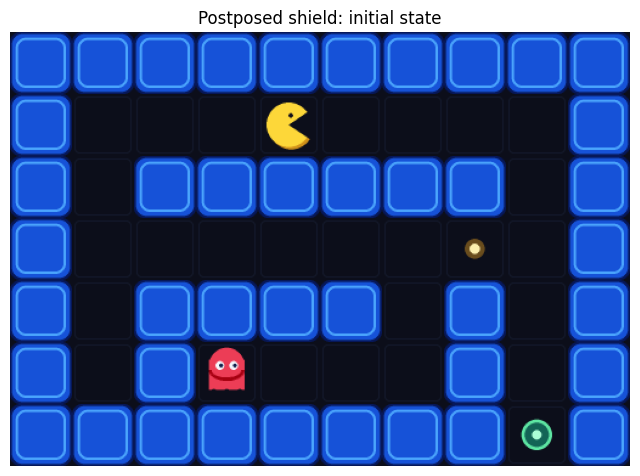

In [19]:
postposed_env = PostposedLTLShield(
    make_monitored_env(),
    replacement=random_safe(seed=REPLACEMENT_SEED),
)

obs, info = postposed_env.reset(seed=ENV_SEED)

# Both wrappers should synthesize the same winning region and safe-action table.
np.testing.assert_array_equal(
    preemptive_env.winning_region,
    postposed_env.winning_region,
)
np.testing.assert_array_equal(
    preemptive_env.safe_actions,
    postposed_env.safe_actions,
)

print("Initial safe actions:", np.flatnonzero(postposed_env.action_masks()).tolist())
show_frame(postposed_env.render(), "Postposed shield: initial state")


In [20]:
def run_postposed(env, steps=MAX_STEPS):
    rng = np.random.default_rng(POLICY_SEED)
    obs, info = env.reset(seed=ENV_SEED)
    rows = []
    frames = [env.render().copy()]

    for t in range(steps):
        mask = env.action_masks()

        # Deliberately ignore the mask when proposing.
        proposed = int(rng.integers(env.action_space.n))

        next_obs, reward, terminated, truncated, step_info = env.step(proposed)

        executed = int(step_info["shield_executed_action"])
        intervened = bool(step_info["shield_intervened"])

        # The executed action must always be certified safe.
        assert mask[executed]

        # Safe proposals must never be changed.
        if mask[proposed]:
            assert executed == proposed
            assert not intervened
        else:
            assert intervened

        assert "ghost" not in step_info.get("labels", set())

        rows.append({
            "step": t + 1,
            "product_state": int(obs),
            "safe_actions": np.flatnonzero(mask).tolist(),
            "proposed": proposed,
            "executed": executed,
            "intervened": intervened,
            "reward": float(reward),
        })

        frames.append(env.render().copy())

        obs, info = next_obs, step_info
        if terminated or truncated:
            break

    return pd.DataFrame(rows), frames


postposed_trace, postposed_frames = run_postposed(postposed_env)
display(postposed_trace.head(15))

interventions = postposed_trace[postposed_trace["intervened"]]
print(
    f"Interventions: {len(interventions)} / {len(postposed_trace)} steps"
)
display(interventions.head(10))

print("Captured RGB frames:", len(postposed_frames))
display(animate_frames(postposed_frames))


,step,product_state,safe_actions,proposed,executed,intervened,reward
0,1,1335,"[0, 1, 2, 3, 4]",0,0,False,0.0
1,2,1611,"[0, 1, 2, 3, 4]",0,0,False,0.0
2,3,1887,"[0, 1, 2, 3, 4]",3,3,False,0.0
3,4,2163,"[0, 1, 2, 3, 4]",2,2,False,0.0
4,5,2411,"[0, 1, 3, 4]",2,0,True,0.0
5,6,2391,"[0, 1, 3, 4]",3,3,False,0.0
6,7,2409,"[0, 1, 2, 3, 4]",3,3,False,0.0
7,8,2409,"[0, 1, 2, 3, 4]",0,0,False,0.0
8,9,2437,"[0, 1, 3, 4]",2,4,True,0.0
9,10,2429,"[0, 1, 2, 3, 4]",0,0,False,0.0


Interventions: 2 / 15 steps


,step,product_state,safe_actions,proposed,executed,intervened,reward
4,5,2411,"[0, 1, 3, 4]",2,0,True,0.0
8,9,2437,"[0, 1, 3, 4]",2,4,True,0.0


Captured RGB frames: 16


### Visualize the first postposed intervention

`postposed_frames[0]` is the reset frame, so row index `i` in the rollout table
corresponds to frame `i` before the action and frame `i + 1` after the executed action.

The image after the step reflects the **executed safe replacement**, not the blocked proposal.


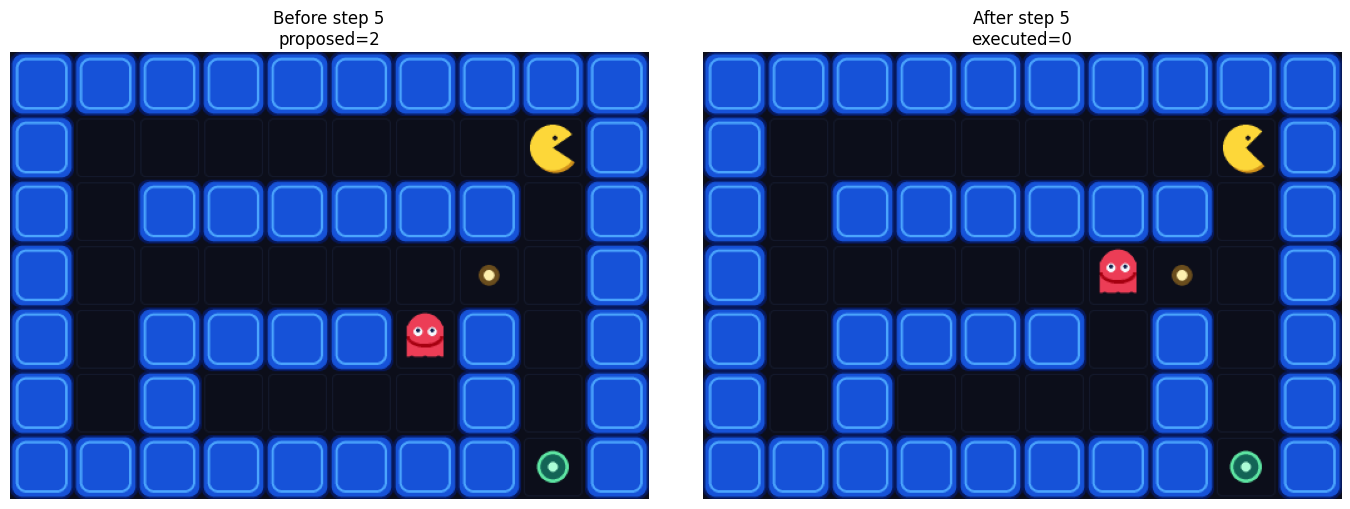

Safe actions before the step: [0, 1, 3, 4]


In [21]:
if interventions.empty:
    print("No intervention occurred with this seed. Try another POLICY_SEED.")
else:
    i = int(interventions.index[0])
    row = postposed_trace.loc[i]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].imshow(postposed_frames[i])
    axes[0].set_title(
        f"Before step {int(row['step'])}\n"
        f"proposed={int(row['proposed'])}"
    )
    axes[0].axis("off")

    axes[1].imshow(postposed_frames[i + 1])
    axes[1].set_title(
        f"After step {int(row['step'])}\n"
        f"executed={int(row['executed'])}"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    print("Safe actions before the step:", row["safe_actions"])


## 5. Compare the two modes

The winning region is the same. The difference is the policy/shield interface:

- **Preemptive:** the learner is responsible for selecting from the mask.
- **Postposed:** the learner may propose anything; unsafe proposals are replaced.

With `random_safe`, replacement itself is stochastic, but safety is not probabilistic:
the replacement is sampled only from actions already in the hard winning-region mask.


In [22]:
summary = pd.DataFrame([
    {
        "mode": "preemptive",
        "steps": len(preemptive_trace),
        "interventions": int(preemptive_trace["intervened"].sum()),
        "reward": float(preemptive_trace["reward"].sum()),
    },
    {
        "mode": "postposed + random_safe",
        "steps": len(postposed_trace),
        "interventions": int(postposed_trace["intervened"].sum()),
        "reward": float(postposed_trace["reward"].sum()),
    },
])

display(summary)


,mode,steps,interventions,reward
0,preemptive,15,0,0.0
1,postposed + random_safe,15,2,0.0


## 6. Important assumptions

The winning-region guarantee assumes:

- the DFA correctly represents a **safety** property;
- `label_fn` is deterministic and unchanged after synthesis;
- the transition model includes every real positive-probability successor;
- the environment uses finite, zero-based discrete state and action spaces;
- the shield is rebuilt if the dynamics, labels, or DFA change.

This tutorial uses the simple property `G !ghost`. It does not optimize food
collection or task completion.

For learning:

- with **preemptive shielding**, apply masks during exploration, exploitation,
  and any next-state action maximization;
- with **postposed shielding**, keep track of the difference between the policy's
  proposed action and the shield's executed action.


### Rendering note

`MiniPacman(render_mode="rgb_array")` makes `env.render()` return a NumPy
`uint8` array with shape `(height, width, 3)`. This is the appropriate mode for
inline Jupyter display. `render_mode="human"` opens a pygame window instead and
does not return an RGB frame.
